In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def load_trading_data(data_folder: str, round_number: int, days: list[int]) -> dict[str, pd.DataFrame]:
    data = {
        'prices': [],
        'trades': []
    }

    for day in days:
        price_file = os.path.join(data_folder, f'prices_round_{round_number}_day_{day}.csv')
        if os.path.exists(price_file):
            price_df = pd.read_csv(price_file, sep=';')
            if 'timestamp' in price_df.columns:
                price_df = price_df.sort_values('timestamp')
            data['prices'].append(price_df)
        
        trade_file = os.path.join(data_folder, f'trades_round_{round_number}_day_{day}.csv')
        if os.path.exists(trade_file):
            trade_df = pd.read_csv(trade_file, sep=';')
            trade_df['day'] = day
            if 'timestamp' in trade_df.columns:
                trade_df = trade_df.sort_values('timestamp')
            data['trades'].append(trade_df)
    
    result = {}
    for key, dfs in data.items():
        if dfs:
            result[key] = pd.concat(dfs, ignore_index=True)

    return result

def get_product_data(df: pd.DataFrame, product: str) -> pd.DataFrame:
    """
    Filter df for specific product (ex: product = "EMERALDS")
    """
    return df[df['product'] == product]

def get_day_data(df: pd.DataFrame, day: int) -> pd.DataFrame:
    """
    Filter df for per day data
    """
    return df[df['day'] == day]

def get_product_day_data(df: pd.DataFrame, product: str, day: int) -> pd.DataFrame:
    """
    Filter df on both product and day
    """
    return df[df['product'] == product and df['day'] == day]

def get_order_data_per_symbol(df: pd.DataFrame, symbol: str) -> pd.DataFrame:
    """
    Filter order book for orders of the symbol
    """
    return df[df['symbol'] == symbol]

def convert_timestamps(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert timestamps after concatenation
    """
    return df.assign(t=(df['day'] + 2) * 1_000_000 + df['timestamp']).drop(columns=['day', 'timestamp']).sort_values('t')


In [22]:
data = load_trading_data(data_folder='data', round_number=0, days=[-1, -2])
price_data = convert_timestamps(data['prices'])
order_data = convert_timestamps(data['trades'])
order_data

,buyer,seller,symbol,currency,price,quantity,t
631,NaN,NaN,TOMATOES,XIRECS,5008.0,2,900
632,NaN,NaN,TOMATOES,XIRECS,5006.0,3,1700
633,NaN,NaN,EMERALDS,XIRECS,10008.0,7,4000
634,NaN,NaN,TOMATOES,XIRECS,5002.0,3,4100
635,NaN,NaN,EMERALDS,XIRECS,9992.0,5,5200
...,...,...,...,...,...,...,...
626,NaN,NaN,EMERALDS,XIRECS,10008.0,3,1983800
627,NaN,NaN,TOMATOES,XIRECS,4946.0,2,1985100
628,NaN,NaN,EMERALDS,XIRECS,10008.0,6,1985600
629,NaN,NaN,TOMATOES,XIRECS,4956.0,2,1993000


In [28]:
emeralds_data = get_product_data(price_data, "EMERALDS")
tomatoes_data = get_product_data(price_data, "TOMATOES")

In [24]:
emeralds_orders = get_order_data_per_symbol(order_data, "EMERALDS")
tomatoes_orders = get_order_data_per_symbol(order_data, "TOMATOES")

C:\Users\Eduard\AppData\Local\Temp\ipykernel_17576\333698116.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


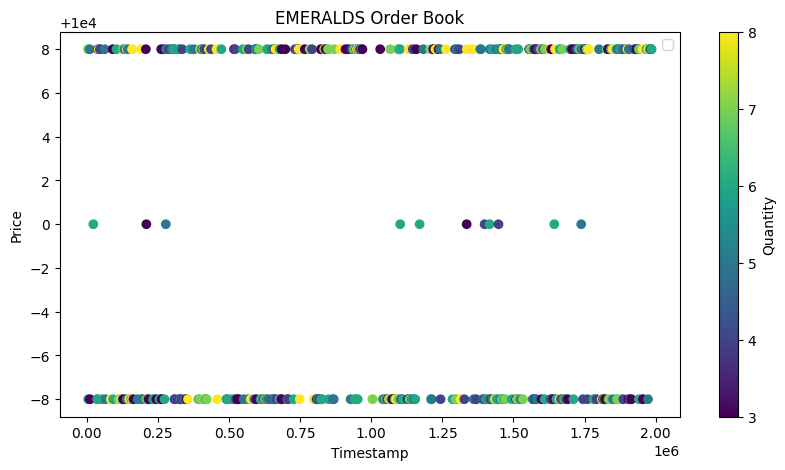

In [26]:
#plotting the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.scatter(emeralds_orders['t'], emeralds_orders['price'], c=emeralds_orders['quantity'], cmap='viridis')
plt.colorbar(label='Quantity')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('EMERALDS Order Book')
plt.legend()
plt.show()

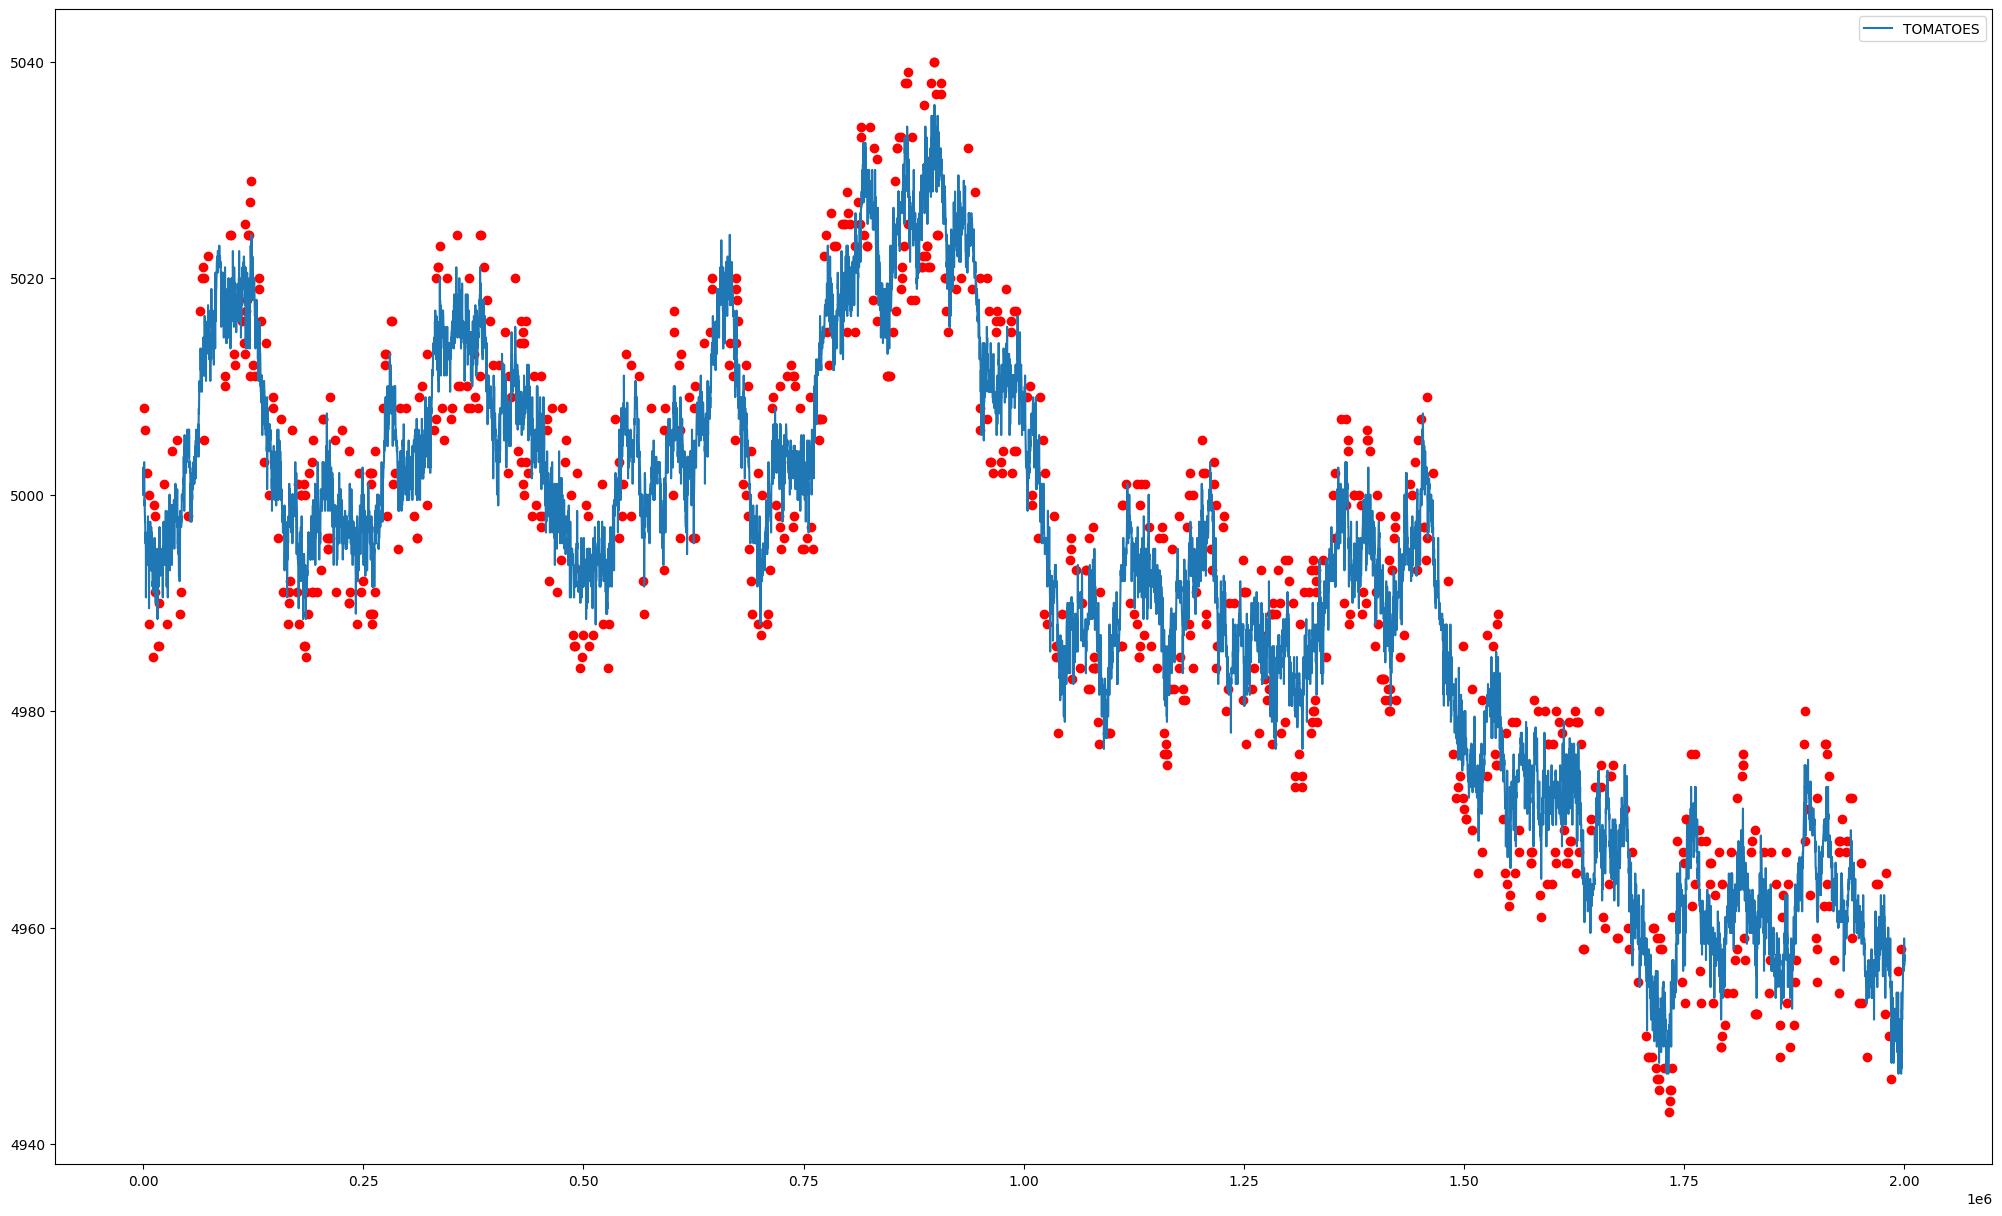

In [36]:
plt.figure(figsize = (25,15))
plt.plot(tomatoes_data['t'], tomatoes_data['mid_price'], label='TOMATOES')
plt.scatter(tomatoes_orders['t'], tomatoes_orders['price'], c='r')
plt.legend()
plt.show()